# **Data Loading**

In [1]:
import pandas as pd
import numpy as np

# The CSV header is malformed: "DiscountDLC count" is two columns merged into one name.
# 39 names vs 40 actual fields — so we supply the corrected names explicitly.
CORRECTED_COLUMNS = [
    'AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price',
    'Discount', 'DLC count',                      # <-- the split that fixes the offset
    'About the game', 'Supported languages', 'Full audio languages', 'Reviews',
    'Header image', 'Website', 'Support url', 'Support email',
    'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
    'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes',
    'Average playtime forever', 'Average playtime two weeks',
    'Median playtime forever', 'Median playtime two weeks',
    'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'
]

# Load only the columns we need — the text/URL fields are what make this file 383 MB
KEEP = ['AppID', 'Name', 'Release date', 'Required age', 'Price', 'Supported languages',
        'Windows', 'Mac', 'Linux', 'Positive', 'Negative', 'Achievements',
        'Developers', 'Genres', 'Tags', 'Categories']

df = pd.read_csv('games.csv', header=0, names=CORRECTED_COLUMNS,
                 usecols=KEEP, low_memory=False)

print("Shape:", df.shape)
print(f"Memory: {df.memory_usage(deep=True).sum()/1e6:.0f} MB")
print(df.head())

Shape: (125855, 16)
Memory: 86 MB
     AppID                                   Name  Release date  Required age  \
0  2539430             Black Dragon Mage Playtest   Aug 1, 2023             0   
1   496350  Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016             0   
2  1034400      Mystery Solitaire The Black Raven   May 6, 2019             0   
3  3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024             0   
4  3631080                          Maze Quest VR  Apr 24, 2025             0   

   Price                         Supported languages  Windows    Mac  Linux  \
0   0.00                                          []     True  False  False   
1   5.24                                 ['English']     True  False  False   
2   4.99  ['English', 'French', 'German', 'Russian']     True   True  False   
3   8.99                                  ['Korean']     True  False  False   
4   4.99                                 ['English']     True  False  False   

   P

# **Fix Verification**

In [2]:
sample = df.iloc[1]
print("Name        :", sample['Name'])
print("Release date:", sample['Release date'])
print("Price       :", sample['Price'])
print("Genres      :", sample['Genres'])
print("Windows     :", sample['Windows'])

Name        : Supipara - Chapter 1 Spring Has Come!
Release date: Jul 29, 2016
Price       : 5.24
Genres      : Adventure
Windows     : True


# **Problem and Target Define**

In [3]:
df['release_dt'] = pd.to_datetime(df['Release date'], format='mixed', errors='coerce')
df['total_reviews'] = df['Positive'] + df['Negative']

print("Date range:", df['release_dt'].min(), "→", df['release_dt'].max())
print("Failed to parse:", df['release_dt'].isna().sum())
print()
print("Review-count coverage:")
for t in [0, 10, 30, 50, 100, 500]:
    n = (df['total_reviews'] >= t).sum()
    print(f"  >= {t:4d} reviews: {n:7,} games ({n/len(df)*100:5.1f}%)")

Date range: 1997-06-30 00:00:00 → 2026-12-01 00:00:00
Failed to parse: 0

Review-count coverage:
  >=    0 reviews: 125,855 games (100.0%)
  >=   10 reviews:  56,662 games ( 45.0%)
  >=   30 reviews:  37,826 games ( 30.1%)
  >=   50 reviews:  30,624 games ( 24.3%)
  >=  100 reviews:  22,804 games ( 18.1%)
  >=  500 reviews:  10,507 games (  8.3%)


# **Filter and Clean**

In [4]:
MIN_REVIEWS = 50

before = len(df)
data = df[
    (df['total_reviews'] >= MIN_REVIEWS) &
    df['release_dt'].notna() &
    df['Genres'].notna()
].copy()

# The target: what fraction of players recommended it
data['pct_positive'] = data['Positive'] / data['total_reviews'] * 100

print(f"Eligible games: {len(data):,} of {before:,} ({len(data)/before*100:.1f}%)")
print(f"  removed for <{MIN_REVIEWS} reviews : {(df['total_reviews'] < MIN_REVIEWS).sum():,}")
print(f"  removed for unparseable date      : {df['release_dt'].isna().sum():,}")
print(f"  removed for missing genres        : {df['Genres'].isna().sum():,}")
print()
print(data['pct_positive'].describe().round(2))

Eligible games: 30,541 of 125,855 (24.3%)
  removed for <50 reviews : 95,231
  removed for unparseable date      : 0
  removed for missing genres        : 8,423

count    30541.00
mean        78.54
std         15.45
min          7.14
25%         70.06
50%         82.05
75%         90.48
max        100.00
Name: pct_positive, dtype: float64


# **Feature Engineering**

In [5]:
data = data.sort_values('release_dt').reset_index(drop=True)

# --- Timing ---
data['release_year']  = data['release_dt'].dt.year
data['release_month'] = data['release_dt'].dt.month
data['release_quarter'] = data['release_dt'].dt.quarter

# --- Scope / effort proxies ---
data['n_genres']     = data['Genres'].str.count(',') + 1
data['n_categories'] = data['Categories'].fillna('').apply(lambda s: 0 if s == '' else s.count(',') + 1)
data['n_languages']  = data['Supported languages'].fillna('[]').str.count(',') + 1
data['n_platforms']  = data[['Windows', 'Mac', 'Linux']].sum(axis=1)

# --- Pricing ---
data['is_free'] = (data['Price'] == 0).astype(int)

# --- Features / polish ---
data['has_achievements'] = (data['Achievements'] > 0).astype(int)

# --- Developer track record: TIME-AWARE, so no leakage ---
# For each game, count how many games that developer had already released BEFORE it.
# Because we sorted by date first, cumcount() only ever looks backwards.
data['dev_prior_games'] = data.groupby('Developers').cumcount()

print("Engineered features:")
print(data[['Price', 'n_genres', 'n_categories', 'n_languages',
            'n_platforms', 'dev_prior_games', 'Achievements']].describe().round(2))

Engineered features:
          Price  n_genres  n_categories  n_languages  n_platforms  \
count  30541.00  30541.00      30541.00     30541.00     30541.00   
mean       5.53      2.87          5.60         5.85         1.46   
std        7.58      1.34          3.46         8.78         0.75   
min        0.00      1.00          0.00         1.00         1.00   
25%        0.99      2.00          3.00         1.00         1.00   
50%        3.24      3.00          5.00         3.00         1.00   
75%        7.49      4.00          7.00         9.00         2.00   
max      269.99     11.00         29.00       103.00         3.00   

       dev_prior_games  Achievements  
count         30540.00      30541.00  
mean              1.68         41.83  
std               4.83        272.99  
min               0.00          0.00  
25%               0.00          0.00  
50%               0.00         16.00  
75%               1.00         34.00  
max              87.00       9821.00  


# **EDA**

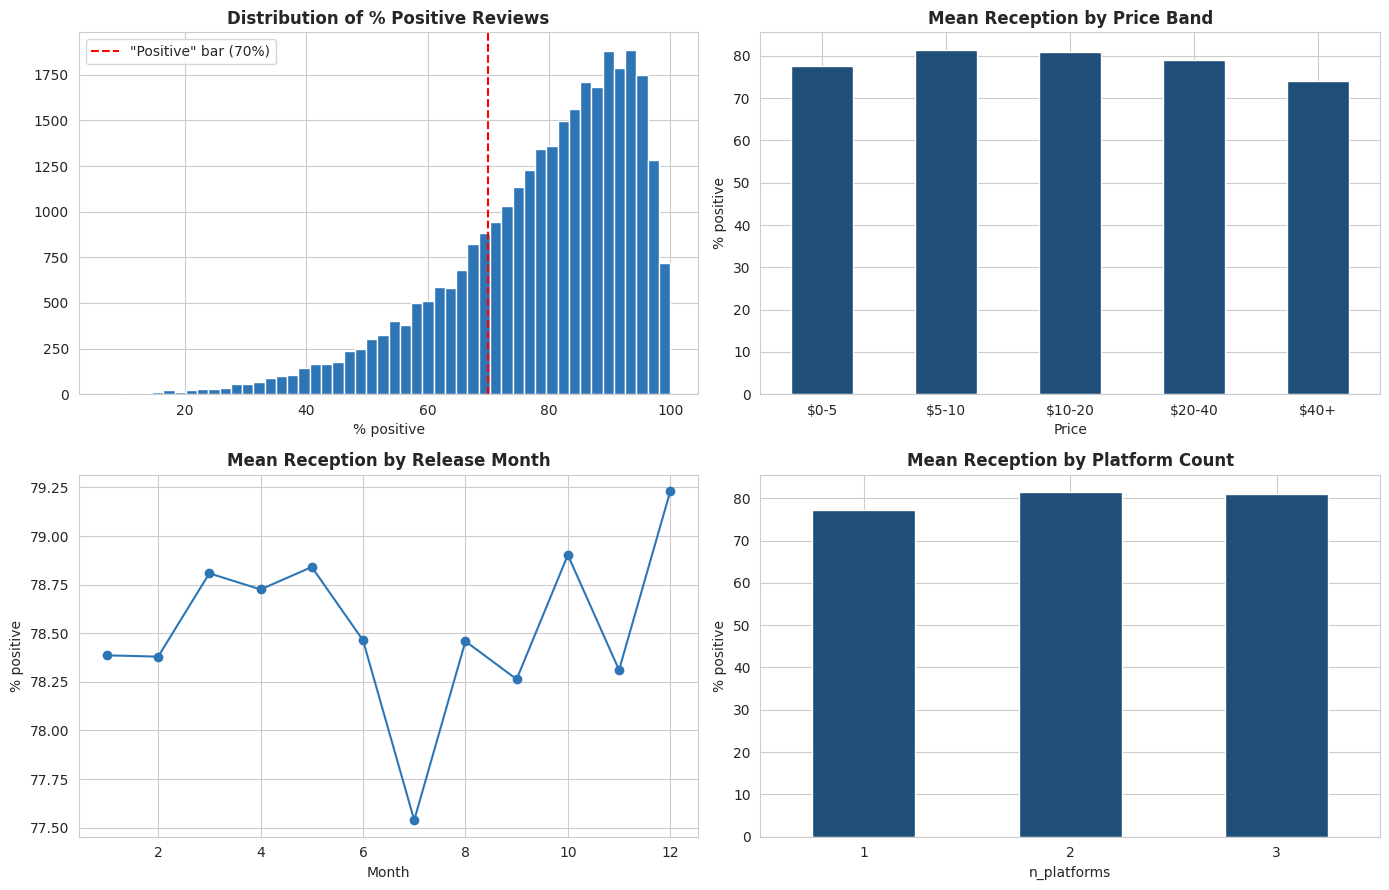

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# Target distribution
ax[0,0].hist(data['pct_positive'], bins=50, color="#2E75B6", edgecolor='white')
ax[0,0].axvline(70, color='red', ls='--', label='"Positive" bar (70%)')
ax[0,0].set_title("Distribution of % Positive Reviews", fontweight='bold')
ax[0,0].set_xlabel("% positive"); ax[0,0].legend()

# Price vs reception
priced = data[data['Price'] > 0]
bands = pd.cut(priced['Price'], [0, 5, 10, 20, 40, 300],
               labels=['$0-5', '$5-10', '$10-20', '$20-40', '$40+'])
priced.groupby(bands, observed=True)['pct_positive'].mean().plot(
    kind='bar', ax=ax[0,1], color="#1F4E79")
ax[0,1].set_title("Mean Reception by Price Band", fontweight='bold')
ax[0,1].set_ylabel("% positive"); ax[0,1].tick_params(axis='x', rotation=0)

# Release month
data.groupby('release_month')['pct_positive'].mean().plot(
    marker='o', ax=ax[1,0], color="#2E75B6")
ax[1,0].set_title("Mean Reception by Release Month", fontweight='bold')
ax[1,0].set_xlabel("Month"); ax[1,0].set_ylabel("% positive")

# Platforms
data.groupby('n_platforms')['pct_positive'].mean().plot(
    kind='bar', ax=ax[1,1], color="#1F4E79")
ax[1,1].set_title("Mean Reception by Platform Count", fontweight='bold')
ax[1,1].set_ylabel("% positive"); ax[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

In [8]:
numeric_feats = ['Price', 'Required age', 'Achievements', 'n_genres', 'n_categories',
                 'n_languages', 'n_platforms', 'is_free', 'has_achievements',
                 'dev_prior_games', 'release_year', 'release_month']

corr = (data[numeric_feats + ['pct_positive']].corr()['pct_positive']
        .drop('pct_positive').sort_values(key=abs, ascending=False))
print(corr.round(3))

release_year        0.208
has_achievements    0.149
n_platforms         0.106
n_genres           -0.095
n_categories        0.089
is_free            -0.059
Price               0.057
n_languages         0.054
Achievements       -0.033
Required age       -0.008
dev_prior_games     0.007
release_month       0.003
Name: pct_positive, dtype: float64


# **Model Feature Set**

In [9]:
# One game has a missing Developers value, which makes groupby().cumcount() return NaN.

# Fix it before engineering, or LinearRegression will crash on the NaN.
data['Developers'] = data['Developers'].fillna('Unknown')
data['dev_prior_games'] = data.groupby('Developers').cumcount()

# Genre indicators — one column per major genre
TOP_GENRES = ['Indie', 'Adventure', 'Action', 'Casual', 'Simulation', 'RPG',
              'Strategy', 'Free To Play', 'Early Access', 'Sports', 'Racing',
              'Massively Multiplayer']
for g in TOP_GENRES:
    data['genre_' + g.replace(' ', '_')] = data['Genres'].str.contains(g, regex=False).astype(int)

# Category indicators — these are developer-set features, all pre-launch
TOP_CATS = ['Single-player', 'Multi-player', 'Steam Achievements', 'Steam Cloud',
            'Full controller support', 'Steam Trading Cards', 'Co-op', 'Steam Workshop']
for c in TOP_CATS:
    data['cat_' + c.replace(' ', '_').replace('-', '_')] = (
        data['Categories'].fillna('').str.contains(c, regex=False).astype(int))

FEATURES = (['Price', 'Required age', 'Achievements', 'n_genres', 'n_categories',
             'n_languages', 'n_platforms', 'is_free', 'has_achievements',
             'dev_prior_games', 'release_year', 'release_month']
            + ['genre_' + g.replace(' ', '_') for g in TOP_GENRES]
            + ['cat_' + c.replace(' ', '_').replace('-', '_') for c in TOP_CATS])

X = data[FEATURES]
y = data['pct_positive']

print(f"Features: {len(FEATURES)}   Rows: {len(X):,}")
print("NaN check:", X.isna().sum().sum())    # must be 0

Features: 32   Rows: 30,541
NaN check: 0


# **Regression**

In [10]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def eval_reg(name, model, scale=False):
    t = time.time()
    if scale:
        model = Pipeline([('scaler', StandardScaler()), ('model', model)])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name:26s} RMSE={rmse:6.3f}  MAE={mean_absolute_error(y_test, pred):6.3f}  "
          f"R²={r2_score(y_test, pred):7.4f}  ({time.time()-t:.1f}s)")
    return model, pred

# Baseline: predict the training mean for everything
mean_pred = np.full(len(y_test), y_train.mean())
print(f"{'[baseline] predict mean':26s} RMSE={np.sqrt(mean_squared_error(y_test, mean_pred)):6.3f}  "
      f"MAE={mean_absolute_error(y_test, mean_pred):6.3f}  R²={r2_score(y_test, mean_pred):7.4f}")

lin, _ = eval_reg("LinearRegression", LinearRegression(), scale=True)
rf,  _ = eval_reg("RandomForest", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
hgb, _ = eval_reg("HistGradientBoosting", HistGradientBoostingRegressor(max_iter=300, random_state=42))

[baseline] predict mean    RMSE=15.459  MAE=12.243  R²=-0.0002
LinearRegression           RMSE=14.249  MAE=11.133  R²= 0.1502  (0.6s)
RandomForest               RMSE=13.495  MAE=10.524  R²= 0.2377  (35.0s)
HistGradientBoosting       RMSE=13.339  MAE=10.385  R²= 0.2553  (1.0s)


# **Classification**

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

y_cls = (y >= 70).astype(int)   # Steam's "Positive" threshold

X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
    X, y, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

print(f"Class balance: {c_train.mean()*100:.1f}% clear the 70% bar\n")

def eval_cls(name, model, scale=False):
    if scale:
        model = Pipeline([('scaler', StandardScaler()), ('model', model)])
    model.fit(X_train, c_train)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"{name:32s} acc={accuracy_score(c_test, pred):.4f} "
          f"prec={precision_score(c_test, pred):.4f} rec={recall_score(c_test, pred):.4f} "
          f"f1={f1_score(c_test, pred):.4f} auc={roc_auc_score(c_test, proba):.4f}")
    return model, pred, proba

# The trivial baseline: say "yes" to everything
always_yes = np.ones(len(c_test), dtype=int)
print(f"{'[baseline] always predict yes':32s} acc={accuracy_score(c_test, always_yes):.4f} "
      f"prec={precision_score(c_test, always_yes):.4f} rec=1.0000 "
      f"f1={f1_score(c_test, always_yes):.4f} auc=0.5000")

eval_cls("LogisticRegression", LogisticRegression(max_iter=2000), scale=True)
eval_cls("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
hgb_c, pred_c, proba_c = eval_cls("HistGradientBoosting",
                                  HistGradientBoostingClassifier(max_iter=300, random_state=42))
eval_cls("HistGB (class_weight=balanced)",
         HistGradientBoostingClassifier(max_iter=300, random_state=42, class_weight='balanced'))

Class balance: 75.2% clear the 70% bar

[baseline] always predict yes    acc=0.7518 prec=0.7518 rec=1.0000 f1=0.8583 auc=0.5000
LogisticRegression               acc=0.7518 prec=0.7682 rec=0.9595 f1=0.8532 auc=0.6950
RandomForest                     acc=0.7757 prec=0.7943 rec=0.9469 f1=0.8639 auc=0.7450
HistGradientBoosting             acc=0.7749 prec=0.7933 rec=0.9475 f1=0.8636 auc=0.7472
HistGB (class_weight=balanced)   acc=0.7013 prec=0.8634 rec=0.7159 f1=0.7828 auc=0.7490


(HistGradientBoostingClassifier(class_weight='balanced', max_iter=300,
                                random_state=42),
 array([1, 1, 0, ..., 1, 0, 1]),
 array([0.58745052, 0.77904176, 0.44734987, ..., 0.67433756, 0.40581239,
        0.58362517]))

# **Evaluation**

In [12]:
# Does a model trained specifically on the yes/no question beat

# simply thresholding the regression output at 70?
hgb_r = HistGradientBoostingRegressor(max_iter=300, random_state=42)
hgb_r.fit(X_train, y_train)
pred_thresholded = (hgb_r.predict(X_test) >= 70).astype(int)

print(f"{'thresholded regressor':24s} acc={accuracy_score(c_test, pred_thresholded):.4f} "
      f"prec={precision_score(c_test, pred_thresholded):.4f} "
      f"rec={recall_score(c_test, pred_thresholded):.4f} "
      f"f1={f1_score(c_test, pred_thresholded):.4f}")
print(f"{'dedicated classifier':24s} acc={accuracy_score(c_test, pred_c):.4f} "
      f"prec={precision_score(c_test, pred_c):.4f} "
      f"rec={recall_score(c_test, pred_c):.4f} f1={f1_score(c_test, pred_c):.4f}")

thresholded regressor    acc=0.7762 prec=0.8074 rec=0.9225 f1=0.8611
dedicated classifier     acc=0.7749 prec=0.7933 rec=0.9475 f1=0.8636


# **Time-Based Validation**

In [13]:
train_t = data[data['release_year'] <= 2022]
test_t  = data[data['release_year'] >= 2023]

print(f"Train: {len(train_t):,} games (≤2022)   Test: {len(test_t):,} games (≥2023)")

m = HistGradientBoostingRegressor(max_iter=300, random_state=42)
m.fit(train_t[FEATURES], train_t['pct_positive'])
pred_t = m.predict(test_t[FEATURES])

print(f"  RMSE={np.sqrt(mean_squared_error(test_t['pct_positive'], pred_t)):.3f}  "
      f"R²={r2_score(test_t['pct_positive'], pred_t):.4f}")
print(f"  train mean={train_t['pct_positive'].mean():.2f}  "
      f"test mean={test_t['pct_positive'].mean():.2f}")

Train: 23,140 games (≤2022)   Test: 7,401 games (≥2023)
  RMSE=12.342  R²=0.1474
  train mean=77.11  test mean=82.99


# **Permutation Importance**

In [14]:
from sklearn.inspection import permutation_importance

result = permutation_importance(hgb_r, X_test, y_test, n_repeats=5,
                                random_state=42, n_jobs=-1)
imp = pd.Series(result.importances_mean, index=FEATURES).sort_values(ascending=False)
print(imp.head(12).round(4))

release_year          0.2048
Price                 0.0576
n_categories          0.0378
n_languages           0.0319
cat_Steam_Cloud       0.0278
cat_Multi_player      0.0278
n_platforms           0.0240
Achievements          0.0197
genre_Simulation      0.0187
genre_Early_Access    0.0143
genre_Casual          0.0141
genre_Strategy        0.0136
dtype: float64


# **Model Save**

In [16]:
import joblib, sklearn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, f1_score, roc_auc_score)

# Self-contained: rebuilds the split and both models so it doesn't depend on
# variables from earlier cells (which may have been overwritten).
X = data[FEATURES]
y = data['pct_positive']
y_cls = (y >= 70).astype(int)

X_tr, X_te, y_tr, y_te, c_tr, c_te = train_test_split(
    X, y, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# --- Models for measuring performance (trained on 80%) ---
reg_eval = HistGradientBoostingRegressor(max_iter=300, random_state=42).fit(X_tr, y_tr)
cls_eval = HistGradientBoostingClassifier(max_iter=300, random_state=42).fit(X_tr, c_tr)

pred_r  = reg_eval.predict(X_te)
pred_c  = cls_eval.predict(X_te)
proba_c = cls_eval.predict_proba(X_te)[:, 1]

METRICS = {
    "reg": {
        "RMSE": float(np.sqrt(mean_squared_error(y_te, pred_r))),
        "MAE":  float(mean_absolute_error(y_te, pred_r)),
        "R2":   float(r2_score(y_te, pred_r)),
    },
    "cls": {
        "accuracy": float(accuracy_score(c_te, pred_c)),
        "f1":       float(f1_score(c_te, pred_c)),
        "roc_auc":  float(roc_auc_score(c_te, proba_c)),
    },
}

print("Held-out metrics:")
for task, d in METRICS.items():
    for k, v in d.items():
        print(f"  {task}.{k:9s} = {v:.4f}")

# --- Models for deployment (retrained on ALL data) ---
final_reg = HistGradientBoostingRegressor(max_iter=300, random_state=42).fit(X, y)
final_cls = HistGradientBoostingClassifier(max_iter=300, random_state=42).fit(X, y_cls)

joblib.dump({
    "regressor": final_reg,
    "classifier": final_cls,
    "feature_names": FEATURES,
    "top_genres": TOP_GENRES,
    "top_cats": TOP_CATS,
    "metrics": METRICS,
    "train_year_min": int(data['release_year'].min()),
    "train_year_max": int(data['release_year'].max()),
    "n_train": int(len(data)),
    "sklearn_version": sklearn.__version__,
}, "steam_model.joblib")

print(f"\nSaved steam_model.joblib")

Held-out metrics:
  reg.RMSE      = 13.4489
  reg.MAE       = 10.4221
  reg.R2        = 0.2490
  cls.accuracy  = 0.7749
  cls.f1        = 0.8636
  cls.roc_auc   = 0.7472

Saved steam_model.joblib
